# AIML Lesson 1 — Features and Target

1. ML learns patterns from past examples.
2. Features are input columns available before prediction.
3. Target is the answer we want to predict.
4. In quant, features are market conditions and target is future direction.
5. Next_Return is used to create Target but removed before ML to avoid data leakage.
6. Prediction 1 can later become a long signal; prediction 0 can become no-trade.

## AIML Lesson 2 — Train/Test Split

Train/test split means dividing data into two parts.

The model learns patterns from training data and is evaluated on testing data.

In normal ML, random split is common. But in quant/time-series data, we should usually split by time order.

So we train on earlier rows and test on later rows.

This avoids future leakage and gives a more realistic check.
split_index = int(len(model_df) * 0.7)

train_df = model_df.iloc[:split_index]
test_df = model_df.iloc[split_index:]

print(train_df.shape)
print(test_df.shape)


## AIML Lesson 3 — Classification

Classification means predicting a class/category.

In this project, the model predicts whether the next return will be positive or not.

Target = 1 means next return is positive.
Target = 0 means next return is not positive.

So this is a binary classification problem because there are only two possible outputs: 0 or 1.

In [1]:
# Prices Return Features Next_Return Target feature_cols model_df train_df test_df

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = [100, 102, 101, 103, 105, 104, 106, 108, 107, 109,
111, 110, 108, 106, 104, 103, 101, 100, 98, 99,
101, 103, 102, 104, 106, 108, 110, 109, 111, 113,
112, 110, 108, 107, 105, 103, 104, 106, 108, 107,
109, 111, 113, 115, 114, 116, 118, 117, 115, 113,
112, 110, 108, 109, 111, 113, 112, 114, 116, 118,
117, 119, 121, 120, 122, 124, 123, 121, 119, 120,
122, 124, 126, 125, 127, 129, 128, 130, 132, 131]

fast_window = 5
slow_window = 10

df = pd.DataFrame({'Prices' : data})
df['Return'] = df['Prices'].pct_change()
df['Momentum_3'] = df['Prices'].pct_change(3)
df['Momentum_5'] = df['Prices'].pct_change(5)
df['Volatility_5'] = df['Return'].rolling(window=5).std()
df['Volatility_10'] = df['Return'].rolling(window=10).std()
df['MA_5'] = df['Prices'].rolling(window=5).mean()
df['MA_10'] = df['Prices'].rolling(window=10).mean()                                      
df['MA_Ratio'] =   df['MA_5']/df['MA_10']        
df['Distance_From_MA_10']= (df['Prices'] - df['MA_10'])/df['MA_10']
df['Previous_Return_1'] = df['Return'].shift(1)
df['Previous_Return_2'] = df['Return'].shift(2)
df['Next_Return'] = df['Return'].shift(-1)
df['Target'] = np.where(df['Next_Return'] >0,1,0)

feature_cols = ['Momentum_3','Momentum_5','Volatility_5','Volatility_10','MA_Ratio','Distance_From_MA_10','Previous_Return_1','Previous_Return_2']

model_df = df[feature_cols + ['Next_Return','Target']]
model_df = model_df.dropna()
model_df = model_df[feature_cols + ['Target']]

split_index = int(len(model_df) * 0.7)
train_df = model_df.iloc[:split_index]
test_df = model_df.iloc[split_index:]

X_train = train_df[feature_cols]
y_train = train_df['Target']

X_test = test_df[feature_cols]
y_test = test_df['Target']



                                           





In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , confusion_matrix

model = LogisticRegression()
print(model)

model.fit(X_train,y_train)
y_pred = model.predict(X_test)
print(y_pred)

accuracy = accuracy_score(y_test ,y_pred)
print(accuracy)

cm = confusion_matrix(y_test,y_pred)
print(cm,'cm')

prediction_df = pd.DataFrame({
    'Actual' : y_test.values,
    'Predict' : y_pred
})

prediction_df

# Target Distribution
print('Train Target Distribution :')
print(y_train.value_counts())
print('\nTest Target Distribution :')
print(y_test.value_counts())
print('\nPrediction Distribution :')
print(pd.Series(y_pred).value_counts())
print('\n Accuracy :',accuracy)
print('\n Confusion Matrix :',cm)

y_prob = model.predict_proba(X_test)
y_prob

prob_df = pd.DataFrame({
    'Actual' : y_test.values,
    'Predicted' : y_pred ,
    'Probability Class 0' : y_prob[:,0],
    'Probability Class 1' : y_prob[:,1]
})
prob_df.head(10)

prob_df['Probability Class 1'].describe()

custom_threshold = 0.48

pred_threshold = np.where(prob_df['Probability Class 1'] >= 0.48,1,0)
pred_threshold

threshold_accuracy = accuracy_score(y_test.values,pred_threshold)
print(threshold_accuracy)
threshold_confusion_matrix = confusion_matrix(y_test.values,pred_threshold)
print(threshold_confusion_matrix)

# Prediction Distribution
print('Threshold Prediction Distribution')
print(pd.Series(pred_threshold).value_counts())




LogisticRegression()
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
0.38095238095238093
[[ 8  0]
 [13  0]] cm
Train Target Distribution :
Target
0    25
1    23
Name: count, dtype: int64

Test Target Distribution :
Target
1    13
0     8
Name: count, dtype: int64

Prediction Distribution :
0    21
Name: count, dtype: int64

 Accuracy : 0.38095238095238093

 Confusion Matrix : [[ 8  0]
 [13  0]]
0.5238095238095238
[[ 1  7]
 [ 3 10]]
Threshold Prediction Distribution
1    17
0     4
Name: count, dtype: int64


1.1019883203559508
1.1293103448275856


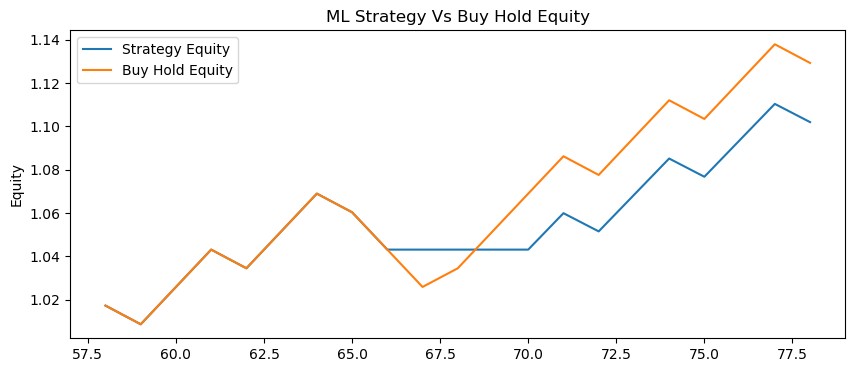

In [36]:
model_full_df =  df[feature_cols + ['Next_Return','Target']]
model_full_df = model_full_df.dropna()
len(model_full_df)

split_index = int(len(model_full_df) * 0.7)
train_model_full_df = model_full_df.iloc[:split_index]
test_model_full_df = model_full_df.iloc[split_index:].copy()

test_model_full_df['Signal'] = pred_threshold
test_model_full_df['Prediction_Return'] = test_model_full_df['Signal']*test_model_full_df['Next_Return']
test_model_full_df[['Next_Return','Target','Signal','Prediction_Return']].head(10)

test_model_full_df['AI_Strategy_Equity_Curve'] = (1 + test_model_full_df['Prediction_Return']).cumprod()
test_model_full_df['Buy_Hold_Equity_Curve'] = (1 + test_model_full_df['Next_Return']).cumprod()
final_strategy_equity = test_model_full_df['AI_Strategy_Equity_Curve'].iloc[-1]
print(final_strategy_equity)
final_buy_hold_equity = test_model_full_df['Buy_Hold_Equity_Curve'].iloc[-1]
print(final_buy_hold_equity)
test_model_full_df

plt.figure(figsize=(10,4))
plt.plot(test_model_full_df['AI_Strategy_Equity_Curve'],label = 'Strategy Equity')
plt.plot(test_model_full_df['Buy_Hold_Equity_Curve'],label = 'Buy Hold Equity')
plt.title('ML Strategy Vs Buy Hold Equity')
plt.ylabel('Equity')

plt.legend()
plt.show()


## AIML Lesson 4 — Logistic Regression

Logistic Regression is a classification model.

It is used when the target is categorical, especially 0 or 1.

In this project, the target is:

- 1 = next return is positive
- 0 = next return is not positive

The model learns from `X_train` and `y_train`.

`X_train` contains the feature columns such as momentum, volatility, MA ratio, distance from MA, and previous returns.

`y_train` contains the correct answer for each training row.

After training, the model predicts on `X_test`.

The output is stored in `y_pred`.

Then we compare `y_pred` with `y_test` using accuracy and confusion matrix.

Accuracy tells the overall percentage of correct predictions.

Confusion matrix shows the detailed breakdown of correct and wrong predictions for class 0 and class 1.

In quant, prediction 1 can later become a long signal, and prediction 0 can become no-trade.

## AIML Lesson 5 — Prediction Distribution

The model accuracy was low because the model predicted only one class.

The confusion matrix showed that the model predicted 0 for every test row.

Checking train distribution, test distribution, and prediction distribution helps us understand whether the model is learning both classes or becoming biased toward one class.

This is important because a model can run successfully but still be practically useless.

## Lesson 6 — Accuracy vs Confusion Matrix Observation

The model accuracy was 38.09%.

Accuracy alone only tells the overall percentage of correct predictions.

The confusion matrix gave deeper information.

The model predicted class 0 for all 21 test rows.

It correctly predicted 8 actual class 0 cases, but failed to predict all 13 actual class 1 cases.

So the model is not useful yet because it never predicted a positive-return signal.

In [ ]:
## AIML Lesson 7 — Why Model Predicted Only One Class

Logistic Regression first calculates probabilities.

For binary classification, it gives probability for class 0 and probability for class 1.

By default, if probability of class 1 is greater than or equal to 0.50, the model predicts 1.

If probability of class 1 is below 0.50, the model predicts 0.

In this project, the model predicted only class 0 because the predicted probabilities for class 1 were likely below the default 0.50 threshold.
                                                                                
So the issue is not that the model cannot output 1. The issue is that its confidence for class 1 was not high enough.

## Lesson 7 — Probability Interpretation

The Logistic Regression model predicted only class 0 because all predicted probabilities for class 1 were below the default 0.50 threshold.

The probability of class 1 ranged only from around 0.476 to 0.484.

This means the model was not highly confident in either direction, but it slightly preferred class 0 for every test row.

So the issue was not that the model could not predict class 1. The issue was that class 1 probability never crossed the default threshold of 0.50.    

## Lesson 8 — Custom Threshold

Logistic Regression first gives probabilities.

The default threshold is 0.50.

If probability of class 1 is greater than or equal to 0.50, prediction becomes 1.

If probability of class 1 is below 0.50, prediction becomes 0.

In the first model, all class 1 probabilities were below 0.50, so the model predicted only class 0.

When the threshold was changed to 0.48, the model started predicting class 1.

The accuracy improved from 38.09% to 52.38%.

However, choosing a threshold after looking at test data can cause overfitting. In real research, threshold should be selected using validation data, not directly on test data.

## Lesson 9 — Convert ML Prediction into Trading Signal

The model prediction was converted into a trading signal.

Prediction 1 means take a long trade.

Prediction 0 means stay out of the market.

The signal was created from the custom-threshold prediction.

The strategy return was calculated as:

ML Strategy Return = Signal × Next_Return

If Signal is 1, the strategy captures the next return.

If Signal is 0, the strategy return is 0 because no trade is taken.

Next_Return was not used as a model feature because that would be data leakage.

But after prediction, Next_Return is used for backtesting the model's trading signal.

In [ ]:
## Lesson 10 — ML Strategy Backtest

The custom-threshold ML prediction was converted into a trading signal.

Prediction 1 was treated as a long signal.

Prediction 0 was treated as no trade.

The ML strategy return was calculated as:

ML_Strategy_Return = Signal × Next_Return

The ML strategy equity curve ended at 1.1019.

The buy-and-hold equity curve ended at 1.1293.

So the ML strategy was profitable, but it did not beat buy-and-hold on this test sample.

This shows that a model can have some predictive value but still may not outperform a simple benchmark.

The result should not be over-trusted because the dataset is small and the threshold was adjusted after observing test behavior.